# Tutorial: parallel echo state networks on the Kuramoto–Sivashinsky equation

A spatially extended chaotic system has a state with many components that
interact locally. In this tutorial, we forecast the Kuramoto–Sivashinsky
equation with three echo state networks:

1. a **global** network: one reservoir that reads and predicts the whole field;
2. a **parallel** network: one reservoir per patch of neighbouring grid points,
   which reads its patch and a halo of points on either side and predicts its
   patch (Pathak et al. 2018). The patches share the input, reservoir and readout
   matrices and the hyperparameters (`patch_size`, `halo`);
3. a **local** network: the parallel layout with independent patches
   (`shared=False`). Every patch has its own matrices, hyperparameters and
   normalization, selected on the record of its own window.

The three networks have the same number of reservoir units in total and train on
the same record. We compare (i) their closed-loop forecasts over several test
windows, (ii) their long-term statistics against the true system, and (iii) their
training cost. The page
[parallel echo state network](https://andreanovoa.github.io/EchoStateNetwork/parallel/)
describes the layout.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np

from echostatenetwork import EchoStateNetwork

plt.rcParams.update({'font.family': 'STIXGeneral', 'mathtext.fontset': 'stix',
                     'font.size': 11, 'axes.titlesize': 11})
COLOURS = {'true': 'k', 'global': 'tab:blue', 'parallel': 'tab:red', 'local': 'tab:green'}

## The Kuramoto–Sivashinsky equation

The Kuramoto–Sivashinsky equation is

$$
\partial_t u + u\,\partial_x u + \partial_x^2 u + \partial_x^4 u = 0,
\qquad x \in [0, L),
$$

where $u(x, t)$ is the field, which is periodic in $x$ with period $L$. The
second derivative injects energy at large scales, the fourth derivative
dissipates it at small scales, and the nonlinear term transfers it between
scales, which makes the dynamics chaotic. The equation is invariant under a shift
in $x$, which is the symmetry that justifies the shared matrices of the parallel
network. Pathak et al. (2018) employ this equation as the test case of the
parallel layout.

We choose a domain of length $L = 22$, a chaotic case whose state space
Cvitanović et al. (2010) analyse in detail, and which keeps the tutorial short.
The field is discretized on $N = 64$ grid points. The linear terms damp the
Fourier modes of wavenumber $k > 1$ at the rate $k^4 - k^2$, so a modest grid
resolves the dissipative scales; the energy spectrum in the section on long-term
statistics checks this. We integrate in Fourier space with the fourth-order
exponential time-differencing Runge–Kutta scheme (ETDRK4) of Kassam & Trefethen
(2005), with the time step of the networks, $\Delta t = 0.25$, as in Pathak et
al. (2018).

In [2]:
def ks_stepper(L, N, dt):
    """One ETDRK4 step of the Kuramoto-Sivashinsky equation (Kassam & Trefethen 2005)
    for fields u of shape (N, m): m independent trajectories advance together."""
    k = 2 * np.pi / L * np.fft.rfftfreq(N, d=1.0 / N)
    lin = k ** 2 - k ** 4                                   # linear operator in Fourier space
    E, E2 = np.exp(dt * lin), np.exp(dt * lin / 2)
    roots = np.exp(1j * np.pi * (np.arange(1, 17) - 0.5) / 16)   # contour integrals
    LR = dt * lin[:, None] + roots[None, :]
    Q = dt * np.real(np.mean((np.exp(LR / 2) - 1) / LR, axis=1))
    f1 = dt * np.real(np.mean((-4 - LR + np.exp(LR) * (4 - 3 * LR + LR ** 2)) / LR ** 3, axis=1))
    f2 = dt * np.real(np.mean((2 + LR + np.exp(LR) * (-2 + LR)) / LR ** 3, axis=1))
    f3 = dt * np.real(np.mean((-4 - 3 * LR - LR ** 2 + np.exp(LR) * (4 - LR)) / LR ** 3, axis=1))
    E, E2, Q, f1, f2, f3, g = (c[:, None] for c in (E, E2, Q, f1, f2, f3, -0.5j * k))

    def nonlinear(v):
        return g * np.fft.rfft(np.fft.irfft(v, n=N, axis=0) ** 2, axis=0)

    def step(u):
        v = np.fft.rfft(u, axis=0)
        Nv = nonlinear(v)
        a = E2 * v + Q * Nv
        Na = nonlinear(a)
        b = E2 * v + Q * Na
        Nb = nonlinear(b)
        c = E2 * a + Q * (2 * Nb - Nv)
        v = E * v + Nv * f1 + 2 * (Na + Nb) * f2 + nonlinear(c) * f3
        return np.fft.irfft(v, n=N, axis=0)

    return step


L, N, DT = 22.0, 64, 0.25
ks_step = ks_stepper(L, N, DT)
x = np.arange(N) * L / N

rng = np.random.default_rng(0)
u = 0.1 * rng.standard_normal((N, 1))
u -= u.mean()
for _ in range(4000):                    # transient onto the attractor (1000 time units)
    u = ks_step(u)
N_TRAIN, N_TEST = 20000, 12000           # record steps: training and test
record = np.empty((N_TRAIN + N_TEST, N))
for n in range(record.shape[0]):
    u = ks_step(u)
    record[n] = u[:, 0]
train_data, test_data = record[:N_TRAIN], record[N_TRAIN:]

We measure time in Lyapunov times, $1/\lambda_1$, in which $\lambda_1$ is the
leading Lyapunov exponent. We estimate $\lambda_1$ from the separation of two
nearby trajectories, renormalized at every step (Benettin et al. 1980).

In [3]:
eps, n_lyap_est = 1e-7, 16000
pair = np.hstack([record[-1][:, None]] * 2)
pair[:, 1] += eps * rng.standard_normal(N) / np.sqrt(N)
pair[:, 1] = pair[:, 0] + eps * (pair[:, 1] - pair[:, 0]) / np.linalg.norm(pair[:, 1] - pair[:, 0])
log_growth = np.empty(n_lyap_est)
for n in range(n_lyap_est):
    pair = ks_step(pair)
    d = np.linalg.norm(pair[:, 1] - pair[:, 0])
    log_growth[n] = np.log(d / eps)
    pair[:, 1] = pair[:, 0] + eps * (pair[:, 1] - pair[:, 0]) / d
LAMBDA_1 = log_growth[400:].mean() / DT          # the first 100 time units align the separation
STEPS_LYAP = int(round(1 / LAMBDA_1 / DT))       # network steps per Lyapunov time
print(f'leading Lyapunov exponent {LAMBDA_1:.3f}: one Lyapunov time = {1 / LAMBDA_1:.1f} '
      f'time units = {STEPS_LYAP} steps')
print(f'record: {N_TRAIN / STEPS_LYAP:.0f} Lyapunov times for training and validation, '
      f'{N_TEST / STEPS_LYAP:.0f} for testing')

leading Lyapunov exponent 0.049: one Lyapunov time = 20.3 time units = 81 steps
record: 247 Lyapunov times for training and validation, 148 for testing


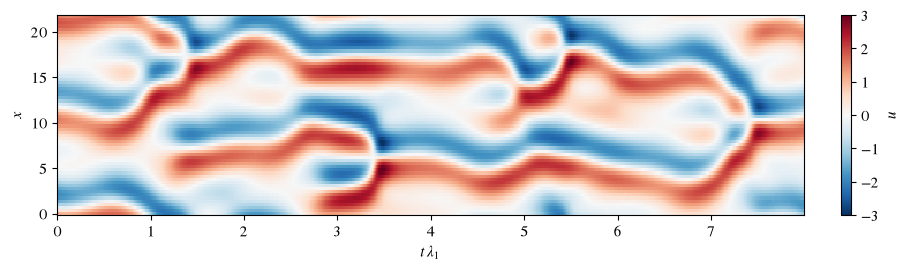

In [4]:
n_show = 8 * STEPS_LYAP
fig, ax = plt.subplots(figsize=(9, 2.6), layout='constrained')
pc = ax.pcolormesh(np.arange(n_show) / STEPS_LYAP, x, train_data[:n_show].T, cmap='RdBu_r',
                   vmin=-3, vmax=3, shading='auto')
fig.colorbar(pc, ax=ax, label='$u$')
ax.set(xlabel=r'$t\,\lambda_1$', ylabel='$x$');

*Figure 1. Space–time diagram of the field over the first Lyapunov times of the
training record. The field forms cells, which drift, merge and split
irregularly.*

## Three networks

The parallel and local networks split the $N$ grid points into $P = N/G$ patches
of $G$ points, each with a reservoir of $N_\mathrm{units}$ units, which reads its
patch and a halo of $H$ points on either side. The global network has one
reservoir of $P N_\mathrm{units}$ units, the same number of units in total. We
choose the patch size and the halo from two length scales of the equation.
First, the halo covers the distance over which information travels in one time
step: advection moves the field by $\max|u|\,\Delta t$, and the fourth
derivative spreads it over about $\Delta t^{1/4}$. Second, a patch is smaller
than the wavelength of the fastest-growing linear mode, $2\pi\sqrt{2}$, so that
each reservoir represents part of a cell and the patches cover several cells.
The code below computes these lengths in grid points and checks both choices.

In [5]:
G, H, N_UNITS = 8, 4, 250              # patch size, halo (grid points), units per reservoir
P = N // G
dx = L / N
advection = np.abs(train_data).max() * DT / dx
diffusion = DT ** 0.25 / dx
wavelength = 2 * np.pi * np.sqrt(2) / dx
print(f'{P} patches of {G} grid points with a halo of {H} points; '
      f'{P} x {N_UNITS} = {P * N_UNITS} units in every network')
print(f'one-step travel: advection {advection:.1f} and fourth derivative {diffusion:.1f} grid '
      f'points -> the halo covers both: {H >= max(advection, diffusion)}')
print(f'fastest-growing wavelength {wavelength:.0f} grid points -> a patch is smaller: '
      f'{G < wavelength}')

8 patches of 8 grid points with a halo of 4 points; 8 x 250 = 2000 units in every network
one-step travel: advection 2.2 and fourth derivative 2.1 grid points -> the halo covers both: True
fastest-growing wavelength 26 grid points -> a patch is smaller: True


All three networks select the spectral radius $\rho$, the input scaling
$\sigma_\mathrm{in}$ and the Tikhonov factor by the same Bayesian optimization,
with chaotic recycle validation (Racca & Magri 2021), on the same ranges and with
the same number of evaluations. The local network runs one search per patch, on the record of its window; its
validation forecasts take the halo from the data, so that the search of one
patch does not depend on the other patches.

In [6]:
N_WASH = 50                            # open-loop washout steps before every forecast
common = dict(dt=DT, upsample=1, N_wash=N_WASH, seed=0, verbose=False,
              t_val=2 * STEPS_LYAP * DT, t_train=(N_TRAIN - 2 * STEPS_LYAP) * DT, t_test=0.,
              noise=1e-3, N_folds=4, N_func_evals=12, N_grid=3,
              hyperparameters_to_optimize=['rho', 'sigma_in', 'tikh'],
              rho_range=(0.0, 0.5), sigma_in_range=(-0.5, 1.5), tikh_range=[1e-12, 1e-10, 1e-8])

networks = {
    'global': EchoStateNetwork(train_data[:1].T, N_units=P * N_UNITS, **common),
    'parallel': EchoStateNetwork(train_data[:1].T, N_units=N_UNITS, patch_size=G, halo=H,
                                 **common),
    'local': EchoStateNetwork(train_data[:1].T, N_units=N_UNITS, patch_size=G, halo=H,
                              shared=False, **common),
}

## Training

Each network trains on the same record, with its hyperparameter search. We record
the wall time and count the readout weights that each network keeps. The global
readout couples every unit with every grid point; the parallel readout maps one
reservoir to one patch and serves all patches; the local network keeps one such
readout per patch.

In [7]:
wall_time, readout_weights = {}, {}
for name, esn in networks.items():
    t0 = time.perf_counter()
    esn.train(train_data, plot_training=False)
    wall_time[name] = time.perf_counter() - t0
    readout_weights[name] = (P * (N_UNITS + 1) * G if name == 'local'
                             else esn.Wout.size)

print(f'{"network":10s}{"units":>8s}{"readout weights":>18s}{"searches":>10s}{"wall time":>12s}')
for name, esn in networks.items():
    n_searches = P if name == 'local' else 1
    print(f'{name:10s}{esn.N_r:8d}{readout_weights[name]:18d}{n_searches:10d}'
          f'{wall_time[name]:10.0f} s')

print('\nselected hyperparameters (rho, sigma_in, Tikhonov):')
for name in ('global', 'parallel'):
    esn = networks[name]
    print(f'  {name:9s}: {esn.rho:.3f}, {esn.sigma_in:.3f}, {esn.tikh:.0e}')
for p, net in enumerate(networks['local'].patches):
    print(f'  local {p}  : {net.rho:.3f}, {net.sigma_in:.3f}, {net.tikh:.0e}')

fastest = min(wall_time, key=wall_time.get)
print(f'\nThe {fastest} network trains fastest. The parallel network keeps '
      f'{readout_weights["global"] / readout_weights["parallel"]:.0f} times fewer readout weights '
      f'than the global network and {readout_weights["local"] / readout_weights["parallel"]:.0f} '
      f'times fewer than the local network.')

network      units   readout weights  searches   wall time
global        2000            128064         1        74 s
parallel      2000              2008         1        32 s
local         2000             16064         8        95 s

selected hyperparameters (rho, sigma_in, Tikhonov):
  global   : 0.253, 1.098, 1e-12
  parallel : 0.250, 0.316, 1e-12
  local 0  : 0.279, 1.250, 1e-10
  local 1  : 0.257, 1.536, 1e-12
  local 2  : 0.354, 2.162, 1e-10
  local 3  : 0.250, 1.052, 1e-12
  local 4  : 0.256, 1.009, 1e-12
  local 5  : 0.247, 0.830, 1e-12
  local 6  : 0.279, 0.989, 1e-12
  local 7  : 0.250, 0.990, 1e-12

The parallel network trains fastest. The parallel network keeps 64 times fewer readout weights than the global network and 8 times fewer than the local network.


Look at the spread of the hyperparameters of the local patches. The equation is
invariant under a shift in $x$, so the optimal hyperparameters are the same for
every patch; any difference between patches reflects the finite record and the
finite search budget of each patch.

## Closed-loop forecasts

From each of several test windows, every network is first driven in open loop by
$N_\mathrm{wash}$ steps of true data (washout), and then forecasts in closed loop,
i.e. it feeds back its own output. The normalized error is

$$
E(t) = \frac{\lVert \mathbf{u}_\mathrm{net}(t) - \mathbf{u}(t) \rVert}
{\sqrt{\langle \lVert \mathbf{u} \rVert^2 \rangle}},
$$

where $\mathbf{u}$ is the true state on the grid, $\mathbf{u}_\mathrm{net}$ the
forecast, and $\langle\cdot\rangle$ the time average over the record. The valid
time is the time at which $E$ first exceeds one half. The windows advance as one
ensemble of columns in `step`.

In [8]:
def forecast(esn, data, starts, n_steps):
    """Open-loop washout on data[s - N_WASH:s], then a closed-loop forecast of n_steps
    from every start s (columns of one ensemble); prediction n approximates data[s + n]."""
    r = np.zeros((esn.N_r, len(starts)))
    for k in range(esn.N_wash, 0, -1):
        u_out, r = esn.step(data[starts - k].T, r)
    out = np.empty((n_steps, data.shape[1], len(starts)))
    for n in range(n_steps):
        out[n] = u_out
        u_out, r = esn.step(esn.outputs_to_inputs(u_out), r)
    return out


N_WINDOWS, N_FORECAST = 20, 4 * STEPS_LYAP
starts = N_WASH + np.arange(N_WINDOWS) * (N_TEST - N_WASH - N_FORECAST) // N_WINDOWS
truth = np.stack([test_data[s:s + N_FORECAST] for s in starts], axis=-1)
scale = np.sqrt(np.mean(np.sum(train_data ** 2, axis=1)))

forecasts, errors, valid_time = {}, {}, {}
for name, esn in networks.items():
    forecasts[name] = forecast(esn, test_data, starts, N_FORECAST)
    errors[name] = np.linalg.norm(forecasts[name] - truth, axis=1) / scale     # (n, window)
    exceeded = errors[name] > 0.5
    valid_time[name] = np.where(exceeded.any(axis=0), exceeded.argmax(axis=0),
                                N_FORECAST) / STEPS_LYAP

for name, vt in valid_time.items():
    q25, q50, q75 = np.percentile(vt, [25, 50, 75])
    print(f'{name:9s} valid time: median {q50:.2f}, interquartile range [{q25:.2f}, {q75:.2f}] '
          f'Lyapunov times')

median = {name: np.median(vt) for name, vt in valid_time.items()}
ranking = sorted(median, key=median.get, reverse=True)
print(f'\nThe {ranking[0]} network forecasts longest, followed by the {ranking[1]} '
      f'and the {ranking[2]} network.')
for a, b in (('parallel', 'global'), ('local', 'global'), ('parallel', 'local')):
    relation = ('longer than' if median[a] > median[b] else
                'shorter than' if median[a] < median[b] else 'as long as')
    overlap = (np.percentile(valid_time[a], 25) <= np.percentile(valid_time[b], 75)
               and np.percentile(valid_time[b], 25) <= np.percentile(valid_time[a], 75))
    print(f'The {a} network forecasts {relation} the {b} network; their interquartile '
          f'ranges {"overlap" if overlap else "do not overlap"}.')

global    valid time: median 1.23, interquartile range [0.96, 1.52] Lyapunov times
parallel  valid time: median 2.02, interquartile range [1.38, 3.17] Lyapunov times
local     valid time: median 1.72, interquartile range [1.37, 2.27] Lyapunov times

The parallel network forecasts longest, followed by the local and the global network.
The parallel network forecasts longer than the global network; their interquartile ranges overlap.
The local network forecasts longer than the global network; their interquartile ranges overlap.
The parallel network forecasts longer than the local network; their interquartile ranges overlap.


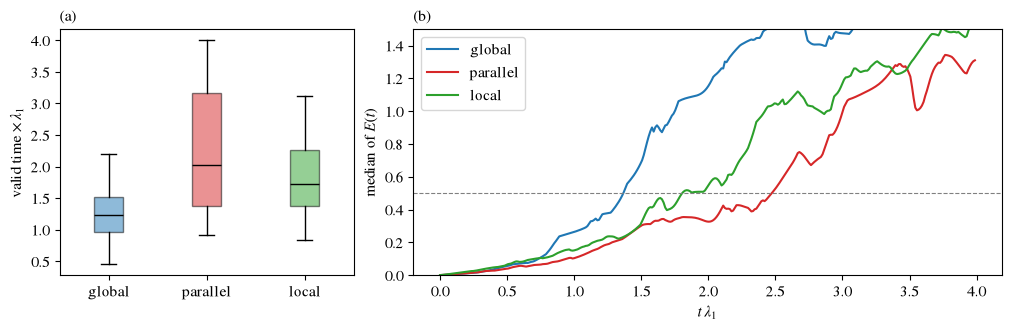

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.2), layout='constrained',
                        gridspec_kw=dict(width_ratios=[1, 2]))
names = list(networks)
box = axs[0].boxplot([valid_time[n] for n in names], tick_labels=names, patch_artist=True,
                     medianprops=dict(color='k'))
for patch, name in zip(box['boxes'], names):
    patch.set(facecolor=COLOURS[name], alpha=0.5)
axs[0].set(ylabel=r'valid time $\times\,\lambda_1$')
t_lyap = np.arange(N_FORECAST) / STEPS_LYAP
for name in names:
    axs[1].plot(t_lyap, np.median(errors[name], axis=1), c=COLOURS[name], label=name)
axs[1].axhline(0.5, c='0.5', ls='--', lw=0.8)
axs[1].set(xlabel=r'$t\,\lambda_1$', ylabel=r'median of $E(t)$', ylim=(0, 1.5))
axs[1].legend(loc='upper left')
for ax, label in zip(axs, '(a) (b)'.split()):
    ax.set_title(label, loc='left');

*Figure 2. Closed-loop forecasts from the test windows. (a) Valid time of each
network: the boxes span the interquartile range and the black line marks the
median. (b) Median over the windows of the normalized error, $E(t)$; the dashed
line marks the threshold of the valid time. Look at the separation of the boxes
relative to their height: it shows whether a difference between networks is
robust across windows.*

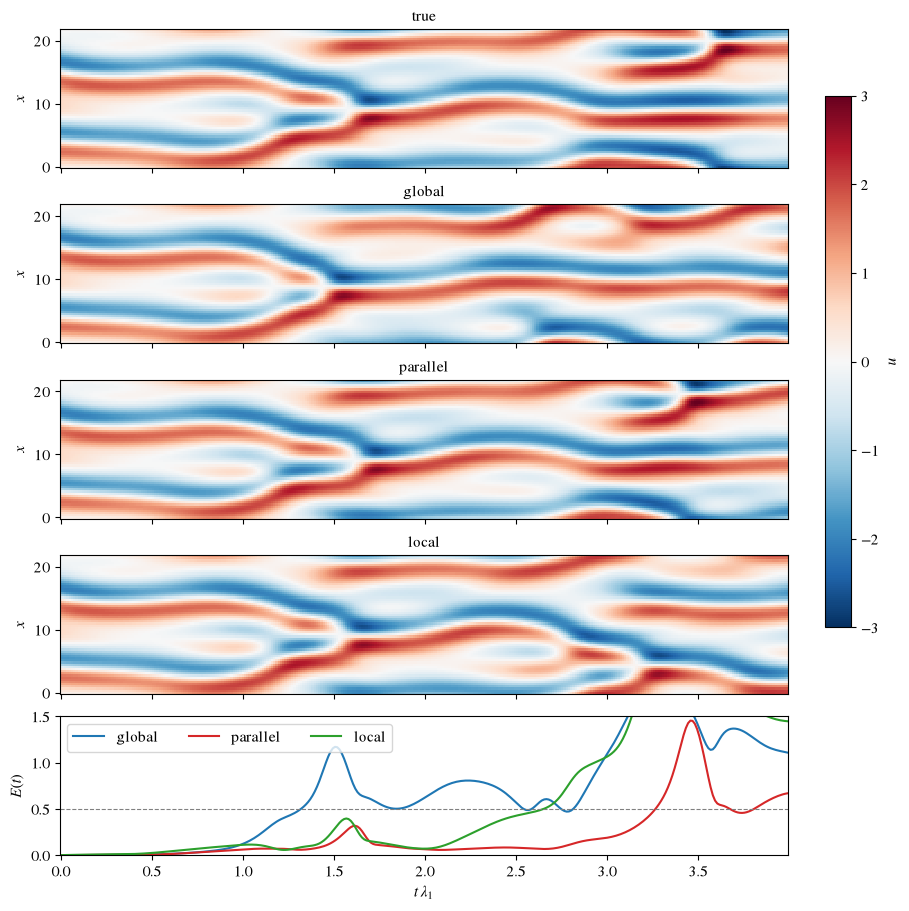

In [10]:
w = 0
fig, axs = plt.subplots(5, 1, figsize=(9, 9), sharex=True, layout='constrained')
panels = [('true', truth[..., w])] + [(n, forecasts[n][..., w]) for n in names]
for ax, (name, field) in zip(axs, panels):
    pc = ax.pcolormesh(t_lyap, x, field.T, cmap='RdBu_r', vmin=-3, vmax=3, shading='auto')
    ax.set(ylabel='$x$', title=name)
fig.colorbar(pc, ax=axs[:4], label='$u$', shrink=0.8)
for name in names:
    axs[4].plot(t_lyap, errors[name][:, w], c=COLOURS[name], label=name)
axs[4].axhline(0.5, c='0.5', ls='--', lw=0.8)
axs[4].set(xlabel=r'$t\,\lambda_1$', ylabel='$E(t)$', ylim=(0, 1.5))
axs[4].legend(loc='upper left', ncol=3);

*Figure 3. One closed-loop forecast, from the first test window. From top to
bottom: the true field, the forecasts of the global, parallel and local networks,
and their normalized errors. Look at where and when each forecast first departs
from the true field.*

## Long-term statistics

After the valid time, a closed-loop forecast is no longer close to the true
trajectory, but it should remain on the attractor. We run every network in closed
loop over many Lyapunov times from half of the test windows, discard an initial
transient, and compare the probability density of $u$ and the energy spectrum,
$\langle |\hat{u}_k|^2 \rangle$, in which $\hat{u}_k$ is the Fourier coefficient of
wavenumber $k$, with the statistics of the test record.

In [11]:
N_LONG = 50 * STEPS_LYAP
long_starts = starts[::2]
bins = np.linspace(-4, 4, 81)
k_axis = 2 * np.pi / L * np.arange(N // 2 + 1)


def statistics(fields):
    """Probability density of u and energy spectrum of fields (n, N[, m])."""
    fields = fields.transpose(0, 2, 1).reshape(-1, N) if fields.ndim == 3 else fields
    density = np.histogram(fields, bins=bins, density=True)[0]
    spectrum = np.mean(np.abs(np.fft.rfft(fields, axis=1) / N) ** 2, axis=0)
    return density, spectrum


stats = {'true': statistics(test_data)}
for name, esn in networks.items():
    fields = forecast(esn, test_data, long_starts, N_LONG)[2 * STEPS_LYAP:]
    if not np.isfinite(fields).all():
        stats[name] = None
        continue
    stats[name] = statistics(fields)
    peak = np.abs(fields).max() / np.abs(test_data).max()
    if peak > 1.5:
        print(f'The {name} network leaves the attractor in closed loop: its largest |u| is '
              f'{peak:.1f} times the largest true value.')

resolved = stats['true'][1] > 1e-12 * stats['true'][1].max()    # wavenumbers above round-off
print(f'true energy spectrum: highest resolved wavenumber / maximum = '
      f'{stats["true"][1][-1] / stats["true"][1].max():.0e}')
distance = {}
for name in names:
    if stats[name] is None:
        print(f'The {name} network diverges in closed loop.')
        continue
    density_error = 0.5 * np.sum(np.abs(stats[name][0] - stats['true'][0])) * np.diff(bins)[0]
    spectrum_error = np.mean(np.abs(np.log10(stats[name][1][resolved] / stats['true'][1][resolved])))
    distance[name] = (density_error, spectrum_error)
    print(f'{name:9s} total-variation distance of the density {density_error:.3f}, '
          f'mean |log10| error of the spectrum {spectrum_error:.2f}')

for i, quantity in enumerate(('the probability density of u', 'the energy spectrum')):
    closest = min(distance, key=lambda n: distance[n][i])
    print(f'The {closest} network reproduces {quantity} most closely.')

The global network leaves the attractor in closed loop: its largest |u| is 3403.2 times the largest true value.


true energy spectrum: highest resolved wavenumber / maximum = 8e-34
global    total-variation distance of the density 0.227, mean |log10| error of the spectrum 8.32
parallel  total-variation distance of the density 0.009, mean |log10| error of the spectrum 0.47
local     total-variation distance of the density 0.012, mean |log10| error of the spectrum 0.52
The parallel network reproduces the probability density of u most closely.
The parallel network reproduces the energy spectrum most closely.


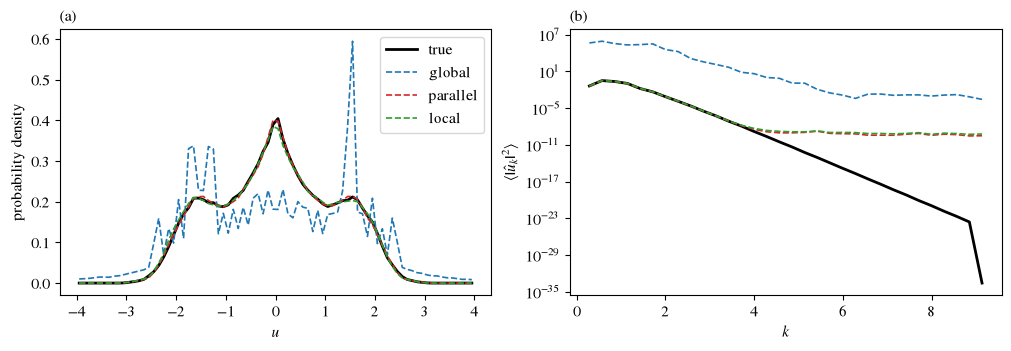

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.4), layout='constrained')
centres = 0.5 * (bins[1:] + bins[:-1])
for name in ['true'] + names:
    if stats[name] is None:
        continue
    style = dict(c=COLOURS[name], lw=2 if name == 'true' else 1.2, label=name,
                 ls='-' if name == 'true' else '--')
    axs[0].plot(centres, stats[name][0], **style)
    axs[1].semilogy(k_axis[1:], stats[name][1][1:], **style)
axs[0].set(xlabel='$u$', ylabel='probability density')
axs[1].set(xlabel='$k$', ylabel=r'$\langle|\hat{u}_k|^2\rangle$')
axs[0].legend()
for ax, label in zip(axs, '(a) (b)'.split()):
    ax.set_title(label, loc='left');

*Figure 4. Long-term statistics of the closed-loop forecasts (dashed) and of the
test record (solid black). (a) Probability density of $u$. (b) Energy spectrum.
Look at the decay of the true spectrum towards the highest wavenumber, which
shows whether the grid resolves the dissipative scales. Look also at the tails of
the density, which measure the extreme values of the field, and at
the large wavenumbers of the spectrum, at which a network that is not smooth
enough adds energy.*

## Summary

The printed verdicts above rank the three networks by forecast accuracy,
long-term statistics and training cost. When reading them, keep in mind what the
layouts change.

- The parallel network fits one readout on $P$ samples per time step, one per
  patch, so each readout weight is trained on $P$ times more data than in the
  local network. Its hyperparameters are selected once, on all the patches.
- The local network adapts every patch: its own matrices, hyperparameters and
  normalization. This freedom pays off when the local dynamics vary in space,
  e.g. with an inhomogeneous forcing, walls or inlets, or sensors of different
  quality. On a periodic domain, the Kuramoto–Sivashinsky equation has no such
  variation, and the optimal hyperparameters of all patches coincide by symmetry.
- The global network has one readout that couples every unit with every grid
  point, and its reservoir state has no position, which covariance localization
  in data assimilation requires (`state_positions` of the parallel and local
  networks).

## References

- Benettin, G., Galgani, L., Giorgilli, A., & Strelcyn, J.-M. (1980). Lyapunov
  characteristic exponents for smooth dynamical systems and for Hamiltonian
  systems; a method for computing all of them. Part 1: Theory. *Meccanica*, 15,
  9–20.
- Cvitanović, P., Davidchack, R. L., & Siminos, E. (2010). On the state space
  geometry of the Kuramoto–Sivashinsky flow in a periodic domain. *SIAM Journal
  on Applied Dynamical Systems*, 9, 1–33.
- Kassam, A.-K., & Trefethen, L. N. (2005). Fourth-order time-stepping for stiff
  PDEs. *SIAM Journal on Scientific Computing*, 26, 1214–1233.
- Pathak, J., Hunt, B., Girvan, M., Lu, Z., & Ott, E. (2018). Model-free
  prediction of large spatiotemporally chaotic systems from data: a reservoir
  computing approach. *Physical Review Letters*, 120, 024102.
- Racca, A., & Magri, L. (2021). Robust optimization and validation of echo state
  networks for learning chaotic dynamics. *Neural Networks*, 142, 252–268.